In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
X_train_trans=pd.read_csv("/content/X_Train_Trans.csv")
X_test_trans=pd.read_csv("/content/X_Test_Trans.csv")
y_train=pd.read_csv("/content/y_Train.csv")
y_test=pd.read_csv("/content/y_test.csv")

In [ ]:
print(X_train_trans.shape)
print(X_test_trans.shape)
print(y_train.shape)


(12000, 16)
(3000, 16)
(12000, 1)


In [ ]:
y_train=y_train.values.ravel()


In [ ]:
y_train.shape

(12000,)

In [ ]:
y_train=pd.DataFrame(y_train)

#Feature Engineering

1. Sleep quality indicator

In [ ]:
X_train_trans["deep_sleep_hours"]=(X_train_trans["sleep_hours"]*X_train_trans["deep_sleep_pct"]/100)

X_test_trans["deep_sleep_hours"]=(X_test_trans["sleep_hours"]*X_test_trans["deep_sleep_pct"]/100)

->This represents the deep sleephours which is easy than looking two seperate variables to know about the deep sleep of that person

In [ ]:
X_train_trans["deep_sleep_hours"].head(5)

,deep_sleep_hours
0,0.020232
1,0.004094
2,-0.004199
3,0.008517
4,-0.013609


2. Notification intensity

In [ ]:
X_train_trans['notifications_per_screen_hour'] = (X_train_trans['notifications_received'] /(X_train_trans['screen_time_min'] / 60 + 1e-6))

X_test_trans['notifications_per_screen_hour'] = (X_test_trans['notifications_received'] /(X_test_trans['screen_time_min'] / 60 + 1e-6))

This gives us how frequently the notifications are popping relative to screen exposure.

In [ ]:
X_train_trans['notifications_per_screen_hour'].head(4)

,notifications_per_screen_hour
0,-428571.428571
1,-19.591165
2,-51.416232
3,-205.763669


3. Work interruption indicator

In [ ]:
X_train_trans['interruption_load'] = (X_train_trans['context_switch_count'] +X_train_trans['notifications_received'])

X_test_trans['interruption_load'] = (X_test_trans['context_switch_count'] +X_test_trans['notifications_received'])

->This gives us the measure of interuption that is related to workload

In [ ]:
X_train_trans['interruption_load'].head(4)

,interruption_load
0,2.571429
1,1.428571
2,0.785714
3,3.857143


#Feature Selection

f_regression test:

In [ ]:
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import SelectKBest

select_columns=SelectKBest(f_regression,k=15)
best_feature=select_columns.fit_transform(X_train_trans,y_train)

# to display best feature names
selected_features=X_train_trans.columns[select_columns.get_support()]
print(selected_features)

Index(['number_of_decisions_made', 'notifications_received', 'screen_time_min',
       'deep_work_min', 'task_complexity_avg', 'caffeine_mg',
       'break_frequency', 'deep_sleep_pct', 'hydration_l', 'mood', 'work_type',
       'noise_level_db', 'workload_score', 'notifications_per_screen_hour',
       'interruption_load'],
      dtype='object')


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mutual infromation

In [ ]:
from sklearn.feature_selection import mutual_info_regression
mutual_info=mutual_info_regression(X_train_trans,y_train)
mutual_info=pd.Series(mutual_info)
mutual_info.index=X_train_trans.columns
mutual_info.sort_values(ascending=False)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,0
workload_score,0.095263
break_frequency,0.080569
number_of_decisions_made,0.030308
hydration_l,0.029991
task_complexity_avg,0.025675
caffeine_mg,0.025067
mood,0.019559
noise_level_db,0.017359
context_switch_count,0.016825
deep_sleep_pct,0.015900


Variance Threshold

In [ ]:
from sklearn.feature_selection import VarianceThreshold
var_thres=VarianceThreshold(threshold=0.1)
var_thres.fit_transform(X_train_trans)
best_features=X_train_trans.columns[var_thres.get_support()]
print(best_features)

Index(['number_of_decisions_made', 'context_switch_count',
       'notifications_received', 'screen_time_min', 'deep_work_min',
       'task_complexity_avg', 'caffeine_mg', 'break_frequency', 'sleep_hours',
       'deep_sleep_pct', 'hydration_l', 'mood', 'work_type', 'noise_level_db',
       'temperature_c', 'workload_score', 'notifications_per_screen_hour',
       'interruption_load'],
      dtype='object')


Dropping of unwanted columns

In [ ]:
columns_to_drop = ['sleep_hours','temperature_c','notifications_per_screen_hour']

X_train_trans = X_train_trans.drop(columns=columns_to_drop)
X_test_trans = X_test_trans.drop(columns=columns_to_drop)

print("X_train_trans shape after dropping columns:", X_train_trans.shape)
print("X_test_trans shape after dropping columns:", X_test_trans.shape)

X_train_trans shape after dropping columns: (12000, 16)
X_test_trans shape after dropping columns: (3000, 16)


-> **sleep_hours**:It showed sufficient variance, but shows zero relevance in the F-regression test and mutual information,so it contributes less useful information.

->**temperature_c**:It has sufficient varinace,but has very weak relevance according to F-regression and Mutual Information, so it can be removed.

->**notifications_per_screen_hour**:Has sufficient variance, but shows very weak predictive information in F-regression and Mutual Information, so it can be removed.

#Model Building

KNN Regression Model

In [ ]:
# Let us bulid a KNN Regression Model
from sklearn.neighbors import KNeighborsRegressor
knn_model=KNeighborsRegressor()
knn_model.fit(X_train_trans,y_train)

KNeighborsRegressor()

In [ ]:
# Let us make prediction using test data
y_pred=knn_model.predict(X_test_trans)


#Hyperparameter Tuning

#Grid SearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error
import numpy as np
tuned_parameters=[{'n_neighbors':[3,5,7,9,11],
                   'p':[1,2]}]

scoring = {
    'R2': 'r2',
    'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
    'RMSE': make_scorer(
        lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
        greater_is_better=False
    )
}
clf= GridSearchCV(estimator=KNeighborsRegressor(),
                  param_grid=tuned_parameters,
                  scoring=scoring,
                  cv=5,
                  return_train_score=True,
                  verbose=1,#optional
                  n_jobs=-1,
                  refit='RMSE' # Explicitly set refit to one of the scoring keys
                  )
clf.fit(X_train_trans,y_train.values.ravel())

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid=[{'n_neighbors': [3, 5, 7, 9, 11], 'p': [1, 2]}],
             refit='RMSE', return_train_score=True,
             scoring={'MAE': make_scorer(mean_absolute_error, greater_is_better=False, response_method='predict'),
                      'R2': 'r2',
                      'RMSE': make_scorer(<lambda>, greater_is_better=False, response_method='predict')},
             verbose=1)

In [ ]:
print("Best Parameters:", clf.best_params_)

print("Best RMSE:", -clf.best_score_)

best_index = clf.best_index_

print("CV R²:", clf.cv_results_['mean_test_R2'][best_index])

print("CV MAE:", -clf.cv_results_['mean_test_MAE'][best_index])

Best Parameters: {'n_neighbors': 11, 'p': 2}
Best RMSE: 8.000699095770024
CV R²: 0.568702844772641
CV MAE: 6.427059166666666


#Model Building

DecisionTreeRegressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt_model=DecisionTreeRegressor()
dt_model.fit(X_train_trans,y_train)

DecisionTreeRegressor()

In [ ]:
# prediction
y_pred=dt_model.predict(X_test_trans)

#Hyperparameter Tuning

GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
import numpy as np

tuned_parameters = [{
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}]

scoring = {
    'R2': 'r2',
    'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
    'RMSE': make_scorer(
        lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
        greater_is_better=False
    )
}

grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=tuned_parameters,
    scoring=scoring,
    refit='RMSE',       # Best model selected based on lowest MAE
    cv=5,
    return_train_score=True,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_trans, y_train.values.ravel())

Fitting 5 folds for each of 45 candidates, totalling 225 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid=[{'max_depth': [3, 5, 7, 10, 15],
                          'min_samples_leaf': [1, 2, 4],
                          'min_samples_split': [2, 5, 10]}],
             refit='RMSE', return_train_score=True,
             scoring={'MAE': make_scorer(mean_absolute_error, greater_is_better=False, response_method='predict'),
                      'R2': 'r2',
                      'RMSE': make_scorer(<lambda>, greater_is_better=False, response_method='predict')},
             verbose=1)

In [ ]:
best_index = grid.best_index_

print("Best Parameters:", grid.best_params_)

print("Best CV RMSE:", -grid.cv_results_['mean_test_RMSE'][best_index])

print("CV R²:", grid.cv_results_['mean_test_R2'][best_index])

print("CV MAE:", -grid.cv_results_['mean_test_MAE'][best_index])

Best Parameters: {'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV RMSE: 9.42531231282399
CV R²: 0.40137565063110336
CV MAE: 7.5678266420800595


#Model Building

LinearRegression

In [ ]:
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()
lr_model.fit(X_train_trans,y_train)

LinearRegression()

In [ ]:
# let us make prediction using test data
y_pred=lr_model.predict(X_test_trans)

#Hyperparameter Tuning

GridsearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
import numpy as np

tuned_parameters = [{
    'fit_intercept': [True, False],
    'positive': [False]
}]

scoring = {
    'R2': 'r2',
    'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
    'RMSE': make_scorer(
        lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
        greater_is_better=False
    )
}

LR_grid = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=tuned_parameters,
    scoring=scoring,
    refit='RMSE',
    cv=5,
    return_train_score=True,
    verbose=1,
    n_jobs=-1
)

LR_grid.fit(X_train_trans, y_train.values.ravel())

Fitting 5 folds for each of 2 candidates, totalling 10 fits


GridSearchCV(cv=5, estimator=LinearRegression(), n_jobs=-1,
             param_grid=[{'fit_intercept': [True, False], 'positive': [False]}],
             refit='RMSE', return_train_score=True,
             scoring={'MAE': make_scorer(mean_absolute_error, greater_is_better=False, response_method='predict'),
                      'R2': 'r2',
                      'RMSE': make_scorer(<lambda>, greater_is_better=False, response_method='predict')},
             verbose=1)

In [ ]:
best_index = LR_grid.best_index_

print("Best Parameters:", LR_grid.best_params_)

print("Best CV RMSE:", -LR_grid.cv_results_['mean_test_RMSE'][best_index])

print("CV R²:", LR_grid.cv_results_['mean_test_R2'][best_index])

print("CV MAE:", -LR_grid.cv_results_['mean_test_MAE'][best_index])

Best Parameters: {'fit_intercept': True, 'positive': False}
Best CV RMSE: 6.697951357773372
CV R²: 0.6977224737880994
CV MAE: 5.358552000353032


#MODEL BUILDING

Ridge

In [ ]:
from sklearn.linear_model import Ridge
model_=Ridge()
model_.fit(X_train_trans,y_train)

Ridge()

In [ ]:
y_pred=model_.predict(X_test_trans)

##Hyperparameter tuning

GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error
import numpy as np

tuned_parameters = [{
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}]

scoring = {
    'R2': 'r2',
    'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
    'RMSE': make_scorer(
        lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
        greater_is_better=False
    )
}

rd_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=tuned_parameters,
    scoring=scoring,
    refit='MAE',
    cv=5,
    return_train_score=True,
    verbose=1,
    n_jobs=-1
)

rd_grid.fit(X_train_trans, y_train.values.ravel())

Fitting 5 folds for each of 7 candidates, totalling 35 fits


GridSearchCV(cv=5, estimator=Ridge(), n_jobs=-1,
             param_grid=[{'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}],
             refit='MAE', return_train_score=True,
             scoring={'MAE': make_scorer(mean_absolute_error, greater_is_better=False, response_method='predict'),
                      'R2': 'r2',
                      'RMSE': make_scorer(<lambda>, greater_is_better=False, response_method='predict')},
             verbose=1)

In [ ]:
best_index = rd_grid.best_index_

print("Best Parameters:", rd_grid.best_params_)

print("Best CV RMSE:", -rd_grid.cv_results_['mean_test_RMSE'][best_index])

print("CV R²:", rd_grid.cv_results_['mean_test_R2'][best_index])

print("CV MAE:", -rd_grid.cv_results_['mean_test_MAE'][best_index])

Best Parameters: {'alpha': 1}
Best CV RMSE: 6.697775053846849
CV R²: 0.697738267404197
CV MAE: 5.358444655060072


#Model Building

Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
rf.fit(X_train_trans,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor()

In [ ]:
y_pred=rf.predict(X_test_trans)

##HYPERPARAMETER TUNING

GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error
import numpy as np

tuned_parameters = [{
     'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}]

scoring = {
    'R2': 'r2',
    'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
    'RMSE': make_scorer(
        lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
        greater_is_better=False
    )
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=tuned_parameters,
    scoring=scoring,
    refit='MAE',
    cv=5,
    return_train_score=True,
    verbose=1,
    n_jobs=-1
)

rf_grid.fit(X_train_trans, y_train.values.ravel())

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid=[{'max_depth': [None, 10], 'min_samples_leaf': [1, 2],
                          'min_samples_split': [2, 5],
                          'n_estimators': [100, 200]}],
             refit='MAE', return_train_score=True,
             scoring={'MAE': make_scorer(mean_absolute_error, greater_is_better=False, response_method='predict'),
                      'R2': 'r2',
                      'RMSE': make_scorer(<lambda>, greater_is_better=False, response_method='predict')},
             verbose=1)

In [ ]:
best_index = rf_grid.best_index_

print("Best Parameters:", rf_grid.best_params_)

print("Best CV RMSE:", -rf_grid.cv_results_['mean_test_RMSE'][best_index])

print("CV R²:", rf_grid.cv_results_['mean_test_R2'][best_index])

print("CV MAE:", -rf_grid.cv_results_['mean_test_MAE'][best_index])

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE: 7.342523917294477
CV R²: 0.6367404041641848
CV MAE: 5.897786038470592


XGB REGRESSOR

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error
import numpy as np

tuned_parameters = [{
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}]

scoring = {
    'R2': 'r2',
    'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
    'RMSE': make_scorer(
        lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
        greater_is_better=False
    )
}

xgb_grid = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=tuned_parameters,
    scoring=scoring,
    refit='MAE',
    cv=5,
    return_train_score=True,
    verbose=1,
    n_jobs=-1
)

xgb_grid.fit(X_train_trans, y_train.values.ravel())

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
             n_jobs=-1,
             param_grid=[{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                          'n_estimators': [100, 200],
                          'subsample': [0.8, 1.0]}],
             refit='MAE', return_train_score=True,
             scoring={'MAE': make_scorer(mean_absolute_error, greater_is_better=False, response_method='predict'),
                      'R2': 'r2',
                      'RMSE': make_scorer(<lambda>, greater_is_better=False, response_method='predict')},
             verbose=1)

In [ ]:
best_index = xgb_grid.best_index_

print("Best Parameters:", xgb_grid.best_params_)

print("Best CV RMSE:", -xgb_grid.cv_results_['mean_test_RMSE'][best_index])

print("CV R²:", xgb_grid.cv_results_['mean_test_R2'][best_index])

print("CV MAE:", -xgb_grid.cv_results_['mean_test_MAE'][best_index])

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV RMSE: 6.283049205564666
CV R²: 0.7339866790437416
CV MAE: 5.0324915436977


Support Vector Regressor

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error
import numpy as np

tuned_parameters = [{
    'kernel': ['linear', 'rbf'],

    'C': [1, 10, 100],

    'epsilon': [0.1],

    'gamma': ['scale', 'auto']
}]

scoring = {
    'R2': 'r2',
    'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
    'RMSE': make_scorer(
        lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
        greater_is_better=False
    )
}

svr_grid = GridSearchCV(
    estimator=SVR(),
    param_grid=tuned_parameters,
    scoring=scoring,
    refit='MAE',
    cv=5,
    return_train_score=True,
    verbose=1,
    n_jobs=-1
)

svr_grid.fit(X_train_trans, y_train.values.ravel())

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=SVR(), n_jobs=-1,
             param_grid=[{'C': [1, 10, 100], 'epsilon': [0.1],
                          'gamma': ['scale', 'auto'],
                          'kernel': ['linear', 'rbf']}],
             refit='MAE', return_train_score=True,
             scoring={'MAE': make_scorer(mean_absolute_error, greater_is_better=False, response_method='predict'),
                      'R2': 'r2',
                      'RMSE': make_scorer(<lambda>, greater_is_better=False, response_method='predict')},
             verbose=1)

In [ ]:
best_index = svr_grid.best_index_

print("Best Parameters:", svr_grid.best_params_)

print("Best CV RMSE:", -svr_grid.cv_results_['mean_test_RMSE'][best_index])

print("CV R²:", svr_grid.cv_results_['mean_test_R2'][best_index])

print("CV MAE:", -svr_grid.cv_results_['mean_test_MAE'][best_index])

Best Parameters: {'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV RMSE: 6.23238475192567
CV R²: 0.7382597614355468
CV MAE: 4.972082870278749


#Model Evaluation

-->Final Model Comparision

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Make sure y_test is 1-dimensional
y_test = y_test.values.ravel()

models = {
    "KNN": clf.best_estimator_,
    "Decision Tree": grid.best_estimator_,
    "Linear Regression": LR_grid.best_estimator_,
    "Ridge": rd_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_,
    "SVR": svr_grid.best_estimator_
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test_trans)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MSE": mse
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="RMSE",
    ascending=True
)

print(results_df)

               Model      RMSE       MAE        R2        MSE
5            XGBoost  6.165276  4.923174  0.744936  38.010630
6                SVR  6.196060  4.929471  0.742382  38.391163
3              Ridge  6.608178  5.301459  0.706973  43.668014
2  Linear Regression  6.608379  5.301703  0.706955  43.670677
4      Random Forest  7.274555  5.824164  0.644894  52.919152
0                KNN  7.940534  6.332297  0.576899  63.052076
1      Decision Tree  9.395611  7.522148  0.407628  88.277507


->From the above reslt ,we can identify that XGBoost works best among all the models.

In [ ]:
best_model = xgb_grid.best_estimator_

print(best_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)


In [ ]:
y_pred = best_model.predict(X_test_trans)

Final Metrics

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Final Model: XGBoost")
print("----------------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

Final Model: XGBoost
----------------------
MAE  : 4.923173746347924
MSE  : 38.010630241187975
RMSE : 6.165276169093156
R²   : 0.744935716939288


#Actual vs Predicted graph

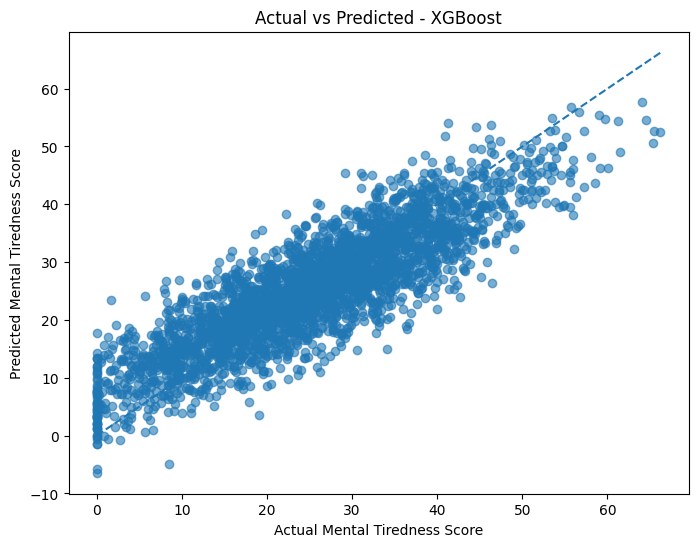

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Mental Tiredness Score")
plt.ylabel("Predicted Mental Tiredness Score")
plt.title("Actual vs Predicted - XGBoost")

plt.show()

* The graph shows that the predicted mental tiredness scores generally follow the actual scores, as most of the points are close to the diagonal line.

* There is still some difference between the actual and predicted values, especially for a few observations, which shows that the model makes some prediction errors.

* Overall, the graph suggests that the XGBoost model is able to predict mental tiredness scores fairly well, which is also supported by its **RMSE of 6.1653 and R² of 0.7444**.


#Residual Analysis

In [ ]:
residuals = y_test - y_pred
residuals

array([ 1.35396255, 18.6607296 ,  1.79389282, ..., -0.20277657,
       -0.70487007,  2.63954292])

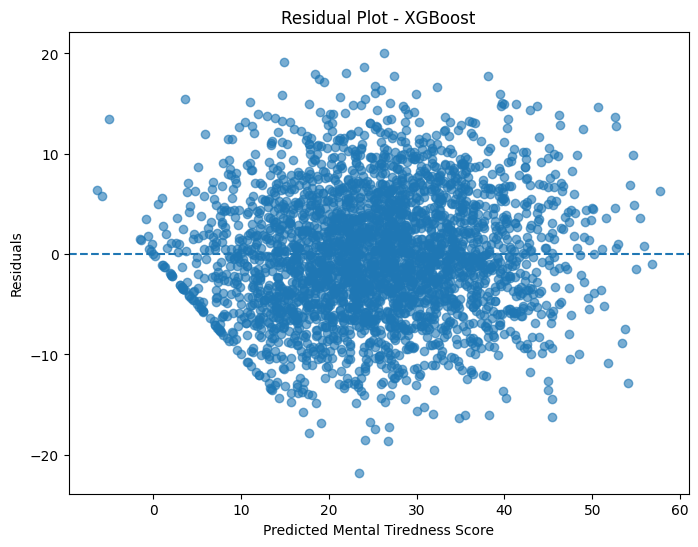

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Mental Tiredness Score")
plt.ylabel("Residuals")
plt.title("Residual Plot - XGBoost")

plt.show()

* The points are mostly spread around the zero line, which means the model's errors are generally small and balanced.

* There is no clear pattern in the points, showing that the model is making predictions reasonably well.

* A few points are far from zero, which means the model has larger errors for some cases.


In [ ]:
import pickle
# Save only the best estimator to avoid pickling the lambda scoring function
best_xgb_model = xgb_grid.best_estimator_
with open("model_pipe.pkl", "wb") as f:
    pickle.dump(best_xgb_model, f)